# Campaign for selling personal loans

Follow the instructions below and create a python notebook to attempt the same :

1. Read the column description and ensure you understand each attribute well
2. Study the data distribution in each attribute, share your findings. (5 points)
3. Get the target column distribution. Your comments (5 points)
4. Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)
5. Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)
6. Print the confusion matrix for all the above models (10 points)
7. Give your reasoning on which is the best model in this case and why it performs better? (10 points)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

%matplotlib inline

import warnings 
warnings.filterwarnings('ignore')

# Load Dataset
## Q1. Read the column description and ensure you understand each attribute well

In [2]:
df = pd.read_csv("Bank_Personal_Loan_Modelling-1.csv")
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [3]:
#Drop ID column
df = df.drop("ID", axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


In [4]:
df.describe()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


### Observation:
- All features are of number data type, no object/string types
- 'Personal Loan' is the dependent/target feature we are trying to predict
- Continious features: Age, Experience, Income, CCAvg, Mortgage
- Discrete features: Family
- Categorical features: ZIP Code, Education, Personal Loan, Securities Account, CD Account, Online, CreditCard

## Convert data type as category for categorical features

In [5]:
for col in ['ZIP Code', 'Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null category
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null category
Mortgage              5000 non-null int64
Personal Loan         5000 non-null category
Securities Account    5000 non-null category
CD Account            5000 non-null category
Online                5000 non-null category
CreditCard            5000 non-null category
dtypes: category(7), float64(1), int64(5)
memory usage: 297.7 KB


## Sanitize data set

In [6]:
print("Number of NULL values in each column:")
print(df.isnull().apply(sum))
print(df.isna().apply(sum))

Number of NULL values in each column:
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


### Observation:
No null or NA values in dataset

Check for 0 values in non categorical features

In [7]:
for col in ["Age", "Experience", "Income", "Family", "CCAvg", "Mortgage"]:
    print( col, sum((df[col]==0)))

Age 0
Experience 66
Income 0
Family 0
CCAvg 106
Mortgage 3462


### Observation:
- 'Age', 'Income' and 'Family' feature has all values
- 'Experience' features has 66 zero values. Can't really say if its a missing data or the customer have no experience. Lets leave zero values here as is.
- 'CCAvg' and 'Mortgage' feature has 106 and 3462 zoro values respectively. Probably this is to mean they donot have any outstanding, so lets leave zero values here as is.

# Exploratory Data Analysis
## Q2. Study the data distribution in each attribute, share your findings. (5 points)

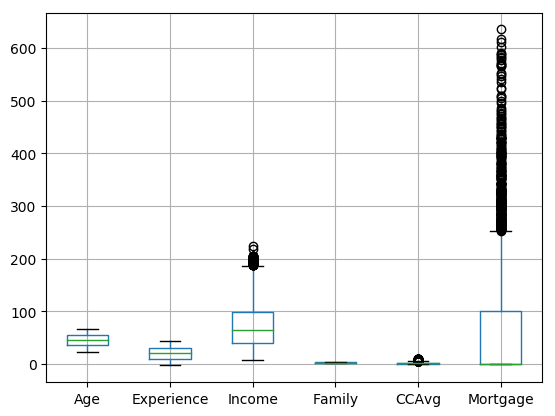

In [8]:
#pd.options.display.mpl_style = 'default'
import matplotlib
matplotlib.style.use('default')

_ = df.boxplot()

### Observations:
- Looks like Mortgage has lots of outliers
- 'Age', 'Experience' and 'Income' seems to be more or less normally distributed, except few outliers for Income

## Feature wise distribution

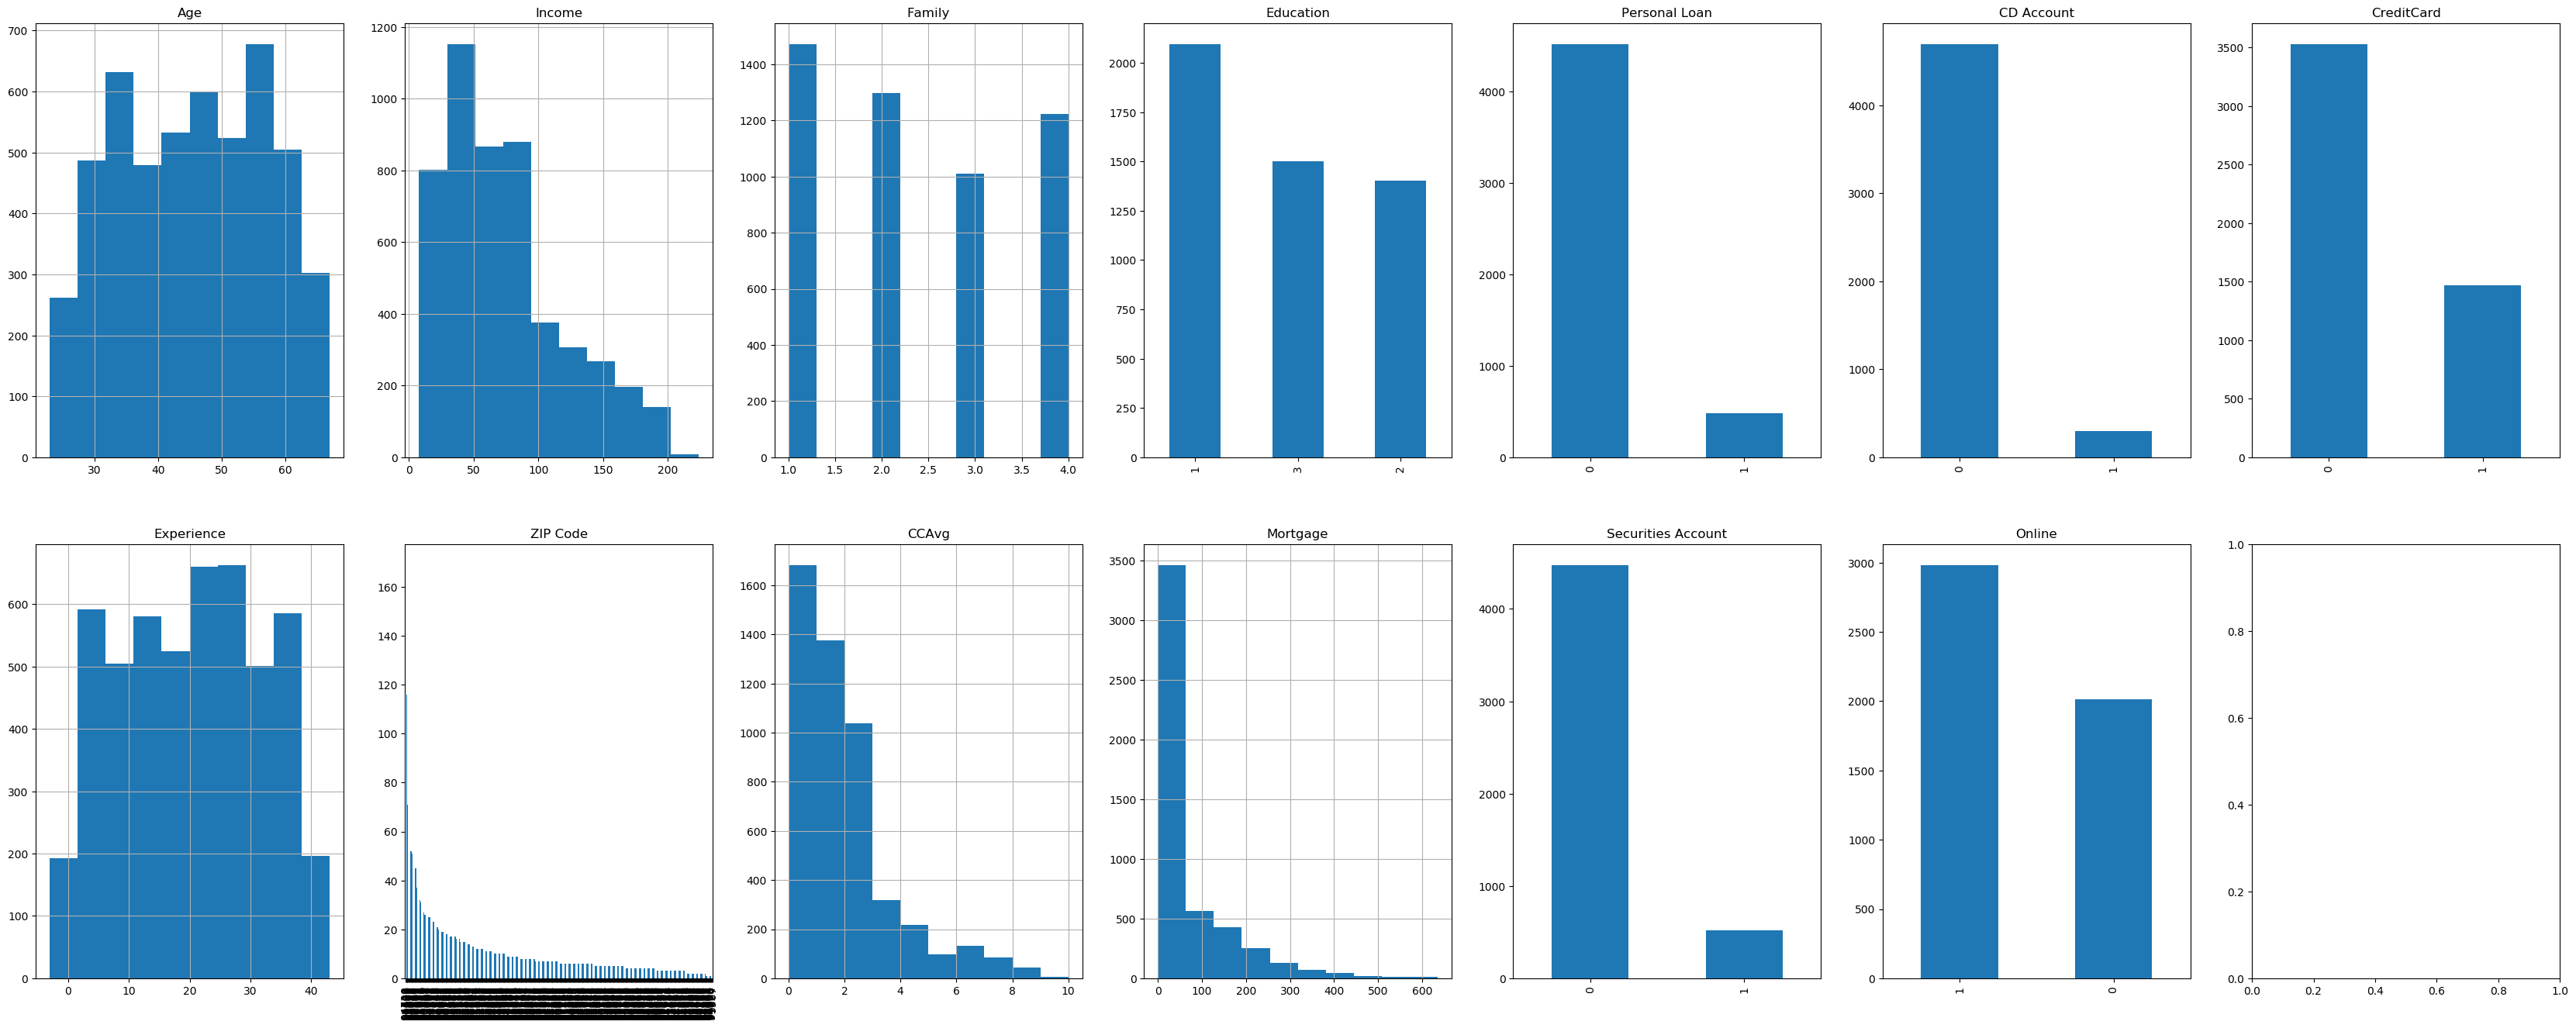

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(42, 16))
for i in range (0,len(df.dtypes.keys())):
    if(df.dtypes[i].name == "category"):
        df[df.dtypes.keys()[i]].value_counts().plot.bar(ax=axes[int(i%2), int(i/2)])
    else:
        df[df.dtypes.keys()[i]].hist(ax=axes[int(i%2), int(i/2)])
    axes[int(i%2), int(i/2)].set_title(df.dtypes.keys()[i])
plt.show()

In [20]:
df.corr()

,Age,Experience,Income,Family,CCAvg,Mortgage,zipmean
Age,1.000000,0.994215,-0.055269,-0.046418,-0.052012,-0.012539,-0.021385
Experience,0.994215,1.000000,-0.046574,-0.052563,-0.050077,-0.010582,-0.019347
Income,-0.055269,-0.046574,1.000000,-0.157501,0.645984,0.206806,0.144863
Family,-0.046418,-0.052563,-0.157501,1.000000,-0.109275,-0.020445,0.017501
CCAvg,-0.052012,-0.050077,0.645984,-0.109275,1.000000,0.109905,0.124275
Mortgage,-0.012539,-0.010582,0.206806,-0.020445,0.109905,1.000000,0.019629
zipmean,-0.021385,-0.019347,0.144863,0.017501,0.124275,0.019629,1.000000


### Observations:
- Age: Sample seems to be normally distributed
- Income: Sample is righ skewed, significant number of people in lower income bracket
- Family: Sample seems to be normally distributed
- Education: Sample seems to be more-or-less evenly distributed
- Personal Loan: Dependent Feature - sigificantly less number of sample availed loan
- CD Account: Significant number of sample donot have CD account
- Credit Card: About 1/3 of the sample have credit card
- Experience: Sample seems to be normally distributed
- Zip Code: Most of the samples are from smaller number of zip code. Probably zipcodes closer to branch locations.
- CCAvg: Most of the sample have zero or closer to zero CCAvg.
- Mortgage: Most of the sample do not have mortgage
- Securities Account: Most of the sample do not have Securities Account
- Online: Most of the sample have online account.

## Q3. Get the target column distribution. Your comments (5 points)

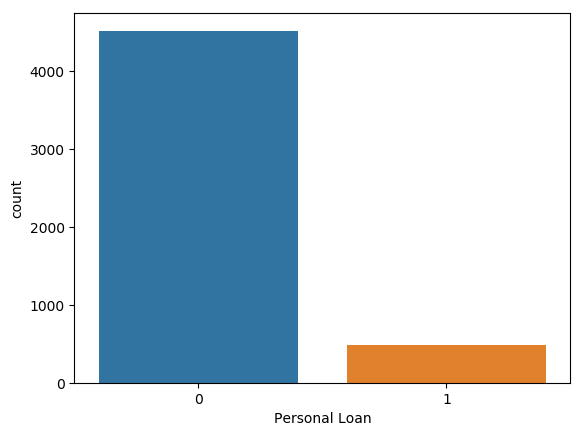

In [10]:
sns.countplot("Personal Loan", data=df)

### Observation:
- Significant number of sample didn't avail personal loan.

# Feature Selection and Scaling

## Dealing with zipcode
'Zip Code' is categorical in nature, but if we do one-HOT encoding it will blow up the column numbers. Also if there is a new ZIP code seen in future, model behaviour might change. 

To make better sense of zipcode, replacing it with the average number of people availed "Personal Loan" in that area.

In [11]:
#Take a copy of df before modifying it
df1 = df.copy()
df["zipmean"]=0
for code in np.unique(df["ZIP Code"]):
    t1 = df[df["ZIP Code"] == code]["Personal Loan"]
    mean = sum(t1)/len(t1)
    df.loc[df["ZIP Code"]==code, "zipmean"] = mean
df = df.drop("ZIP Code", axis=1)
df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,zipmean
0,25,1,49,4,1.6,1,0,0,1,0,0,0,0.120000
1,45,19,34,3,1.5,1,0,0,1,0,0,0,0.173913
2,39,15,11,1,1.0,1,0,0,0,0,0,0,0.112426
3,35,9,100,1,2.7,2,0,0,0,0,0,0,0.000000
4,35,8,45,4,1.0,2,0,0,0,0,0,1,0.065217


### Split X and y features

In [12]:
X = df.drop("Personal Loan", axis=1)
y = df["Personal Loan"]

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ["Age", "Experience", "Income", "Family", "CCAvg", "Mortgage", "zipmean"]
X[cols] = scaler.fit_transform(X[cols])

#Only education has multiple categorical values. So doiing one-HOT encoding only for Education
X = pd.get_dummies(X, columns=["Education"], drop_first=True)
X.head()

,Age,Experience,Income,Family,CCAvg,Mortgage,Securities Account,CD Account,Online,CreditCard,zipmean,Education_2,Education_3
0,-1.774417,-1.666078,-0.538229,1.397414,-0.193385,-0.555524,1,0,0,0,0.273345,0,0
1,-0.029524,-0.096330,-0.864109,0.525991,-0.250611,-0.555524,1,0,0,0,0.887380,0,0
2,-0.552992,-0.445163,-1.363793,-1.216855,-0.536736,-0.555524,0,0,0,0,0.187082,0,0
3,-0.901970,-0.968413,0.569765,-1.216855,0.436091,-0.555524,0,0,0,0,-1.093379,1,0
4,-0.901970,-1.055621,-0.625130,1.397414,-0.536736,-0.555524,0,0,0,1,-0.350594,1,0


## Q4. Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=5)
print("Dataset Size: X_train: {}, X_test: {}, y_train {}, y_test: {}".format(X_train.shape, X_test.shape, y_train.shape, y_test.shape))

Dataset Size: X_train: (3500, 13), X_test: (1500, 13), y_train (3500,), y_test: (1500,)


# Create Models
## Q5. Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, roc_curve, auc


In [16]:
def modelPerformanceAnalysis(X, y, model, test_size = 0.3, seed = 5):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    resultsDf = pd.DataFrame( index=["dataSize", "optimalTh", "accuracy", "recall", "precision", "f1_score"])

    for desc,model in models:
        model.fit(X_train, y_train)
        #### Optimize probability threshold and calculate performance numbers
        y_predictProb = model.predict_proba(X_train)
        fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])
        optimalF1 = 0
        optimalTh = 0
        for th in thresholds:
            preds = np.where(model.predict_proba(X_train)[:,1] > th, 1, 0)
            f1Score = f1_score(y_train, preds)
            if(optimalF1 < f1Score):
                optimalF1 = f1Score
                optimalTh = th

        # Optimal probability threshold based train accuracy numbers
        trainPreds = np.where(model.predict_proba(X_train)[:,1] > optimalTh, 1, 0)
        trainAccuracy = accuracy_score(y_train, trainPreds)
        trainRecall = recall_score(y_train, trainPreds)
        trainPrecision = precision_score(y_train, trainPreds)
        trainF1score = f1_score(y_train, trainPreds)
        optimalTrainResults=[X_train.shape[0], optimalTh, trainAccuracy, trainRecall, trainPrecision, trainF1score]
        # Optimal probability threshold based test accuracy numbers
        testPreds = np.where(model.predict_proba(X_test)[:,1] > optimalTh, 1, 0)
        testAccuracy = accuracy_score(y_test, testPreds)
        testRecall = recall_score(y_test, testPreds)
        testPrecision = precision_score(y_test, testPreds)
        testF1score = f1_score(y_test, testPreds)
        optimalTestResults=[X_test.shape[0], optimalTh, testAccuracy, testRecall, testPrecision, testF1score]
        # Concatenate Train and Test results to resultsDf
        resultsDf[desc+'-TrainResults'] = optimalTrainResults
        resultsDf[desc+'-TestResults'] = optimalTestResults
    
    return resultsDf.round(2)

In [17]:
models = []
lrModel = LogisticRegression()
models.append(("LR", lrModel))
gnbModel = GaussianNB()
models.append(("NB", gnbModel))
knnModel = KNeighborsClassifier(n_neighbors=71)
models.append(("KNN", knnModel))

modelPerformanceAnalysis(X, y, models, test_size = 0.3, seed = 5)

,LR-TrainResults,LR-TestResults,NB-TrainResults,NB-TestResults,KNN-TrainResults,KNN-TestResults
dataSize,3500.00,1500.00,3500.00,1500.00,3500.00,1500.00
optimalTh,0.40,0.40,0.12,0.12,0.23,0.23
accuracy,0.96,0.96,0.88,0.87,0.95,0.94
recall,0.76,0.71,0.82,0.72,0.71,0.59
precision,0.84,0.82,0.44,0.41,0.78,0.72
f1_score,0.80,0.76,0.57,0.52,0.74,0.65


## Q6. Print the confusion matrix for all the above models (10 points)

In [19]:
for (desc,model) in models:
    print("Confusion Matrix for:", desc)
    model.fit(X_train, y_train)
    predicted = model.predict(X_test)
    print(metrics.confusion_matrix(y_true=y_test,y_pred=predicted))

Confusion Matrix for: LR
[[1335   16]
 [  50   99]]
Confusion Matrix for: NB
[[1227  124]
 [  62   87]]
Confusion Matrix for: KNN
[[1351    0]
 [ 115   34]]


### Observation:
Lostistic Regression gives better results in terms of both Type-I and Type-II errors

# Conclusion
## Q7. Give your reasoning on which is the best model in this case and why it performs better? (10 points)

Based on the model performance results and confusion matrix "Logistic Regression" seems to be giving better results compred to "Naive Bayesias" and "KNN" models. It has the lowest Type II errors and second best Type I error and has the best f1 score compared to other models. Also the variance in results between train and test results are minimal compared to other model.

Logistic Regression seems to be doing better as the features are linearly correlated and dont have much multi-collinearity.